In [6]:
import pandas as pd

df = pd.read_csv("../data/train.csv")
df.head()


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [7]:
df["date"] = pd.to_datetime(df["date"])

print("Rows and columns:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate date-store-item rows:",
      df.duplicated(subset=["date", "store", "item"]).sum())

print("\nDate range:", df["date"].min(), "to", df["date"].max())
print("Number of stores:", df["store"].nunique())
print("Number of items:", df["item"].nunique())
print("\nSales summary:")
print(df["sales"].describe())


Rows and columns: (913000, 4)

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate date-store-item rows: 0

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Number of stores: 10
Number of items: 50

Sales summary:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


In [8]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


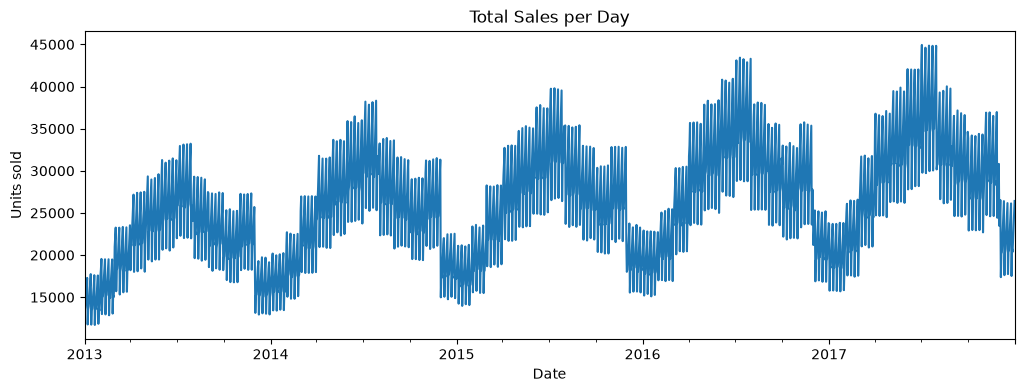

In [9]:
import matplotlib.pyplot as plt

daily_sales = df.groupby("date")["sales"].sum()

daily_sales.plot(
    figsize=(12, 4),
    title="Total Sales per Day"
)
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.show()

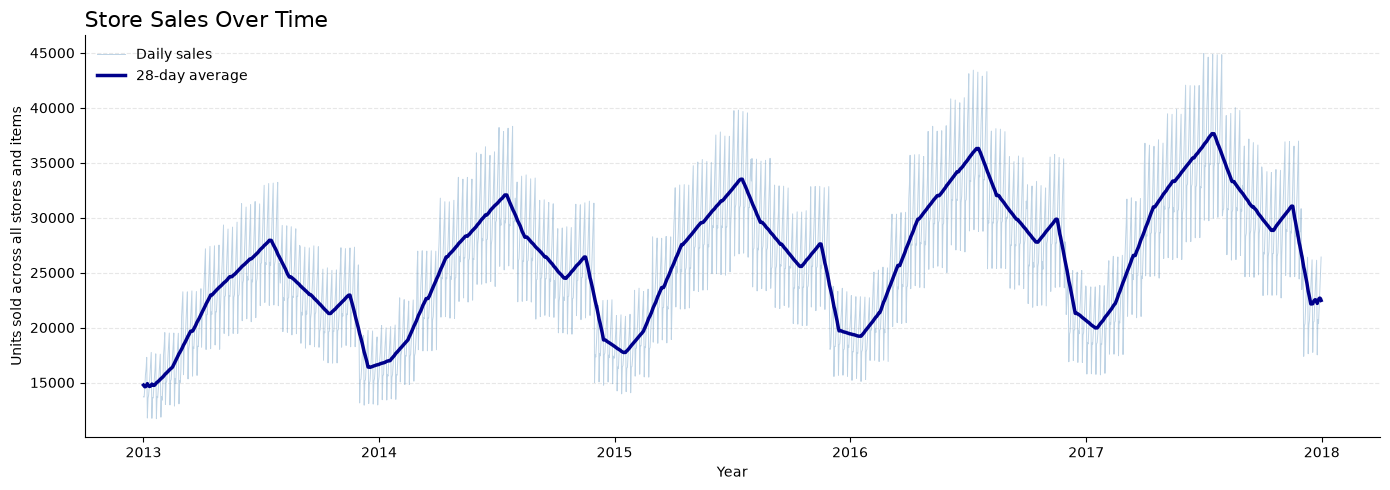

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily_sales = df.groupby("date")["sales"].sum().sort_index()
sales_trend = daily_sales.rolling(
    window=28,
    center=True,
    min_periods=1
).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    daily_sales.index,
    daily_sales,
    color="steelblue",
    linewidth=0.7,
    alpha=0.35,
    label="Daily sales"
)

ax.plot(
    sales_trend.index,
    sales_trend,
    color="darkblue",
    linewidth=2.5,
    label="28-day average"
)

ax.set_title("Store Sales Over Time", fontsize=16, loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Units sold across all stores and items")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

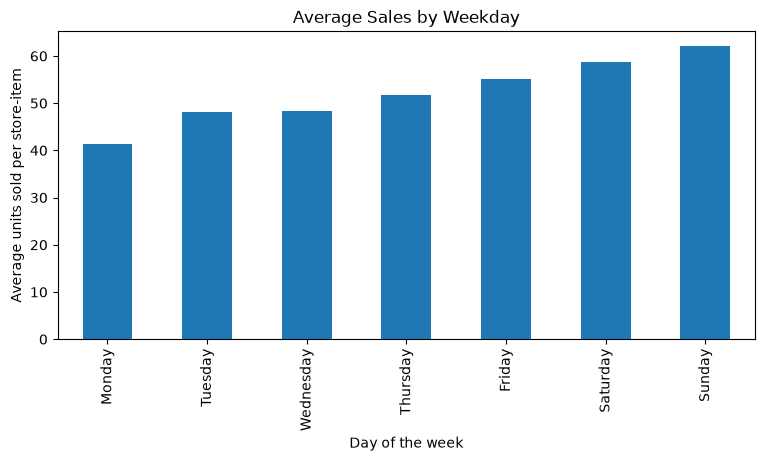

In [11]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_sales = (
    df.groupby(df["date"].dt.day_name())["sales"]
      .mean()
      .reindex(weekday_order)
)

weekday_sales.plot(
    kind="bar",
    figsize=(9, 4),
    title="Average Sales by Weekday"
)
plt.xlabel("Day of the week")
plt.ylabel("Average units sold per store-item")
plt.show()

In [12]:
series = df[
    (df["store"] == 1) & (df["item"] == 1)
].sort_values("date").reset_index(drop=True)

test_days = 14
train = series.iloc[:-test_days]
test = series.iloc[-test_days:].copy()

last_7_days = train["sales"].tail(7).to_list()
test["baseline_prediction"] = last_7_days * 2

display(test[["date", "sales", "baseline_prediction"]])

mae = (
    test["sales"] - test["baseline_prediction"]
).abs().mean()

print("14-day baseline MAE:", round(mae, 2), "units")

,date,sales,baseline_prediction
1812,2017-12-18,19,20
1813,2017-12-19,7,13
1814,2017-12-20,16,17
1815,2017-12-21,12,14
1816,2017-12-22,6,16
1817,2017-12-23,18,15
1818,2017-12-24,19,22
1819,2017-12-25,13,20
1820,2017-12-26,16,13
1821,2017-12-27,14,17


14-day baseline MAE: 4.14 units


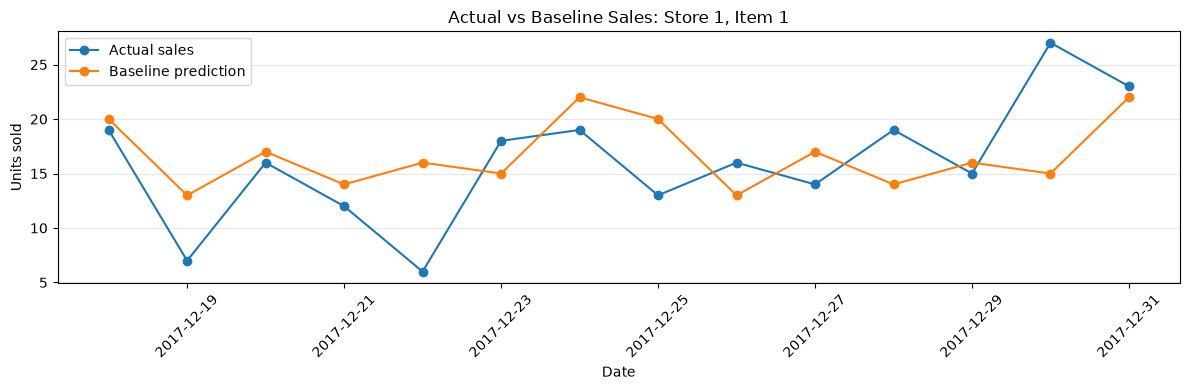

In [13]:
plt.figure(figsize=(12, 4))

plt.plot(
    test["date"],
    test["sales"],
    marker="o",
    label="Actual sales"
)

plt.plot(
    test["date"],
    test["baseline_prediction"],
    marker="o",
    label="Baseline prediction"
)

plt.title("Actual vs Baseline Sales: Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
model_df = df.sort_values(
    ["store", "item", "date"]
).copy()

model_df["day_of_week"] = model_df["date"].dt.dayofweek
model_df["month"] = model_df["date"].dt.month

model_df["lag_7"] = (
    model_df.groupby(["store", "item"])["sales"]
    .shift(7)
)

model_df["rolling_mean_7"] = (
    model_df.groupby(["store", "item"])["sales"]
    .transform(lambda values: values.shift(1).rolling(7).mean())
)

example = model_df[
    (model_df["store"] == 1) & (model_df["item"] == 1)
]

display(
    example[
        [
            "date", "store", "item", "sales",
            "day_of_week", "month", "lag_7", "rolling_mean_7"
        ]
    ].head(10)
)

,date,store,item,sales,day_of_week,month,lag_7,rolling_mean_7
0,2013-01-01,1,1,13,1,1,NaN,NaN
1,2013-01-02,1,1,11,2,1,NaN,NaN
2,2013-01-03,1,1,14,3,1,NaN,NaN
3,2013-01-04,1,1,13,4,1,NaN,NaN
4,2013-01-05,1,1,10,5,1,NaN,NaN
5,2013-01-06,1,1,12,6,1,NaN,NaN
6,2013-01-07,1,1,10,0,1,NaN,NaN
7,2013-01-08,1,1,9,1,1,13.0,11.857143
8,2013-01-09,1,1,12,2,1,11.0,11.285714
9,2013-01-10,1,1,9,3,1,14.0,11.428571


In [15]:
feature_cols = [
    "store", "item", "day_of_week", "month",
    "lag_7", "rolling_mean_7"
]

model_data = model_df.dropna(subset=feature_cols).copy()

cutoff_date = model_df["date"].max() - pd.Timedelta(days=13)

train_data = model_data[model_data["date"] < cutoff_date].copy()
test_actual = model_data[model_data["date"] >= cutoff_date].copy()

print("Training rows:", len(train_data))
print("Training ends:", train_data["date"].max())
print("Test dates:", test_actual["date"].min(), "to", test_actual["date"].max())
print("Test rows:", len(test_actual))


Training rows: 902500
Training ends: 2017-12-17 00:00:00
Test dates: 2017-12-18 00:00:00 to 2017-12-31 00:00:00
Test rows: 7000


In [16]:
%pip install xgboost scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

X_train = train_data[feature_cols]
y_train = train_data["sales"]

X_test = test_actual[feature_cols]
y_test = test_actual["sales"]

model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
predictions = np.maximum(predictions, 0)

xgb_mae = mean_absolute_error(y_test, predictions)
baseline_mae = mean_absolute_error(y_test, test_actual["lag_7"])

print("Baseline MAE:", baseline_mae)
print("XGBoost MAE:", xgb_mae)

Baseline MAE: 7.337571428571429
XGBoost MAE: 6.01579475402832


In [18]:
results = test_actual[
    ["date", "store", "item", "sales", "lag_7"]
].copy()

results = results.rename(columns={
    "sales": "actual_sales",
    "lag_7": "baseline_prediction"
})

results["xgb_prediction"] = predictions
results["xgb_abs_error"] = (
    results["actual_sales"] - results["xgb_prediction"]
).abs()

display(
    results[
        (results["store"] == 1) &
        (results["item"] == 1)
    ].sort_values("date")
)

,date,store,item,actual_sales,baseline_prediction,xgb_prediction,xgb_abs_error
1812,2017-12-18,1,1,19,20.0,14.532119,4.467881
1813,2017-12-19,1,1,7,13.0,15.830316,8.830316
1814,2017-12-20,1,1,16,17.0,14.906618,1.093382
1815,2017-12-21,1,1,12,14.0,15.719970,3.719970
1816,2017-12-22,1,1,6,16.0,16.337860,10.337860
1817,2017-12-23,1,1,18,15.0,16.102015,1.897985
1818,2017-12-24,1,1,19,22.0,17.895679,1.104321
1819,2017-12-25,1,1,13,19.0,12.610872,0.389128
1820,2017-12-26,1,1,16,7.0,13.089617,2.910383
1821,2017-12-27,1,1,14,16.0,13.973709,0.026291


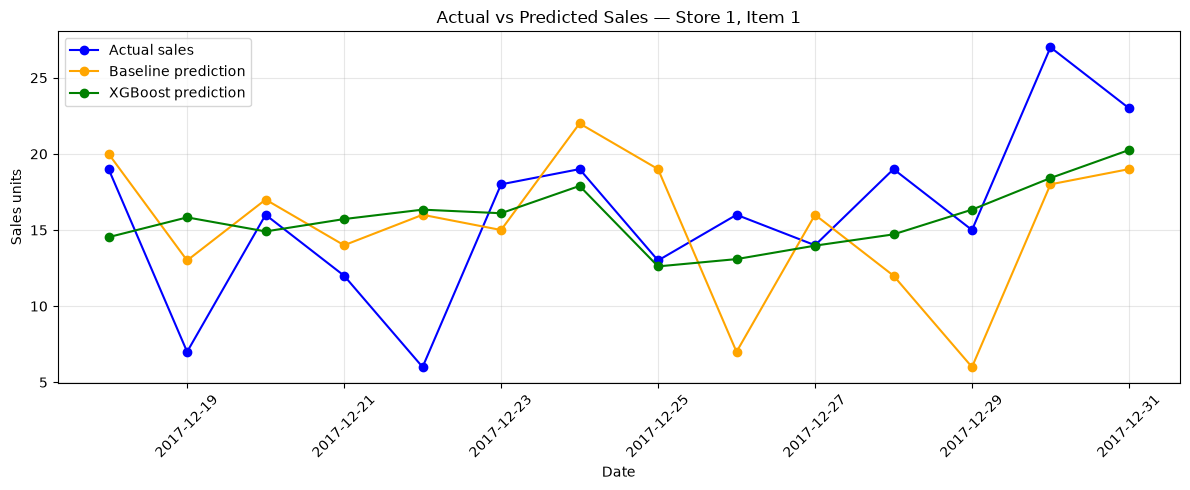

In [19]:
import matplotlib.pyplot as plt

one_item = results[
    (results["store"] == 1) &
    (results["item"] == 1)
].sort_values("date")

plt.figure(figsize=(12, 5))

plt.plot(
    one_item["date"], one_item["actual_sales"],
    marker="o", color="blue", label="Actual sales"
)
plt.plot(
    one_item["date"], one_item["baseline_prediction"],
    marker="o", color="orange", label="Baseline prediction"
)
plt.plot(
    one_item["date"], one_item["xgb_prediction"],
    marker="o", color="green", label="XGBoost prediction"
)

plt.title("Actual vs Predicted Sales — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales units")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,feature,importance
4,lag_7,0.575153
5,rolling_mean_7,0.382387
2,day_of_week,0.035370
3,month,0.005989
0,store,0.000639
1,item,0.000463


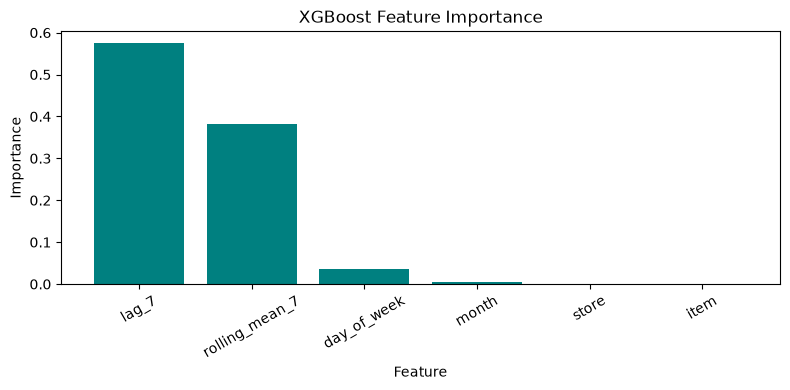

In [20]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 4))
plt.bar(
    importance_df["feature"],
    importance_df["importance"],
    color="teal"
)
plt.title("XGBoost Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [21]:
test_df = pd.read_csv("../data/test.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

test_df["date"] = pd.to_datetime(test_df["date"])

print("Test shape:", test_df.shape)
print("Test columns:", test_df.columns.tolist())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

display(test_df.head())
display(sample_submission.head())

Test shape: (45000, 4)
Test columns: ['id', 'date', 'store', 'item']
Test date range: 2018-01-01 00:00:00 to 2018-03-31 00:00:00


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


,id,sales
0,0,52
1,1,52
2,2,52
3,3,52
4,4,52


In [22]:
final_train_data = model_df.dropna(subset=feature_cols).copy()

final_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    final_train_data[feature_cols],
    final_train_data["sales"]
)

print("Final training rows:", len(final_train_data))
print("Training ends:", final_train_data["date"].max())

Final training rows: 909500
Training ends: 2017-12-31 00:00:00


In [23]:
history_sales = {
    (int(store), int(item)): group.sort_values("date")["sales"].tolist()
    for (store, item), group in df.groupby(["store", "item"])
}

test_sorted = test_df.sort_values(
    ["date", "store", "item"]
).copy()

predicted_rows = []

for forecast_date in sorted(test_sorted["date"].unique()):
    day_data = test_sorted[
        test_sorted["date"] == forecast_date
    ].copy()

    day_data["day_of_week"] = day_data["date"].dt.dayofweek
    day_data["month"] = day_data["date"].dt.month

    day_data["lag_7"] = day_data.apply(
        lambda row: history_sales[
            (int(row["store"]), int(row["item"]))
        ][-7],
        axis=1
    )

    day_data["rolling_mean_7"] = day_data.apply(
        lambda row: np.mean(
            history_sales[
                (int(row["store"]), int(row["item"]))
            ][-7:]
        ),
        axis=1
    )

    day_predictions = final_model.predict(day_data[feature_cols])
    day_predictions = np.maximum(day_predictions, 0)

    predicted_rows.append(
        pd.DataFrame({
            "id": day_data["id"].to_numpy(),
            "sales": day_predictions
        })
    )

    for store, item, prediction in zip(
        day_data["store"],
        day_data["item"],
        day_predictions
    ):
        history_sales[(int(store), int(item))].append(float(prediction))

submission = (
    pd.concat(predicted_rows, ignore_index=True)
    .sort_values("id")
    .reset_index(drop=True)
)

print("Submission shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print("Missing sales predictions:", submission["sales"].isna().sum())

display(submission.head())

Submission shape: (45000, 2)
Columns: ['id', 'sales']
Missing sales predictions: 0


,id,sales
0,0,15.382635
1,1,17.524220
2,2,18.015499
3,3,19.639505
4,4,20.593363


In [24]:
submission.to_csv("../submission.csv", index=False)
print("Submission file saved.")

Submission file saved.
